# UCDP GED v25.1 — Myanmar Exploratory Data Analysis

Explores the UCDP Georeferenced Event Dataset with a focus on Myanmar (Burma):
actors, conflict types, dyads, geographic spread, and fatality trends.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/raw/ucdp/GEDEvent_v25_1.csv'

df = pd.read_csv(DATA_PATH, low_memory=False, parse_dates=['date_start', 'date_end'])
print(f'Full dataset: {len(df):,} events, {df["country"].nunique()} countries, {df["year"].min()}–{df["year"].max()}')

Full dataset: 385,918 events, 124 countries, 1989–2024


## 1. Filter to Myanmar

In [2]:
mm = df[df['country'] == 'Myanmar (Burma)'].copy()

viol_map = {1: 'State-based (1)', 2: 'Non-state (2)', 3: 'One-sided (3)'}
mm['violence_type'] = mm['type_of_violence'].map(viol_map)

print(f'Myanmar events  : {len(mm):,}')
print(f'Year range      : {mm["year"].min()} – {mm["year"].max()}')
print(f'Unique side_a   : {mm["side_a"].nunique()}')
print(f'Unique side_b   : {mm["side_b"].nunique()}')
print(f'Unique conflicts: {mm["conflict_name"].nunique()}')
print(f'Unique dyads    : {mm["dyad_name"].nunique()}')
print(f'Provinces adm_1 : {mm["adm_1"].nunique()}')
mm.head(3)

Myanmar events  : 8,476
Year range      : 1989 – 2024
Unique side_a   : 10
Unique side_b   : 24
Unique conflicts: 20
Unique dyads    : 31
Provinces adm_1 : 24


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob,violence_type
181021,71686,MYA-1989-1-306-35,1989,True,Clear,1,221,221,Myanmar (Burma): Karen,428,...,0,0,0,3,3,0,0,775,NaN,State-based (1)
181022,500136,MYA-1989-1-306-1.2,1989,True,Clear,1,221,221,Myanmar (Burma): Karen,428,...,0,0,4,0,4,4,4,775,NaN,State-based (1)
181023,49166,MYA-1989-1-306-1.1,1989,True,Clear,1,221,221,Myanmar (Burma): Karen,428,...,16,0,0,0,16,16,16,775,NaN,State-based (1)


## 2. Type of Violence

violence_type
Non-state (2)        78
One-sided (3)      2501
State-based (1)    5897


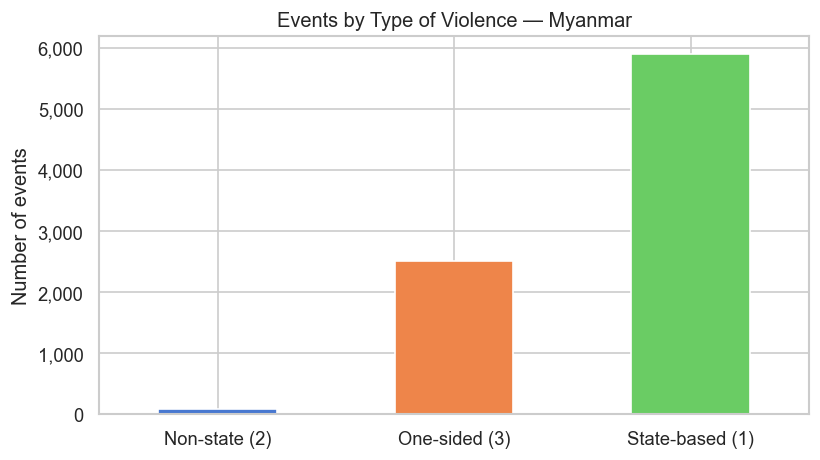

In [3]:
viol_counts = mm['violence_type'].value_counts().sort_index()
print(viol_counts.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
viol_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 3))
ax.set_title('Events by Type of Violence — Myanmar')
ax.set_xlabel('')
ax.set_ylabel('Number of events')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Side A Actors (typically government / initiating armed group)

All Side A actors:
side_a
Government of Myanmar (Burma)    8183
NUG                               163
DKBA                               35
KNU                                27
Buddhists (Myanmar)                25
ARSA                               17
MTA                                 9
ULA                                 8
RCSS                                8
MDA                                 1


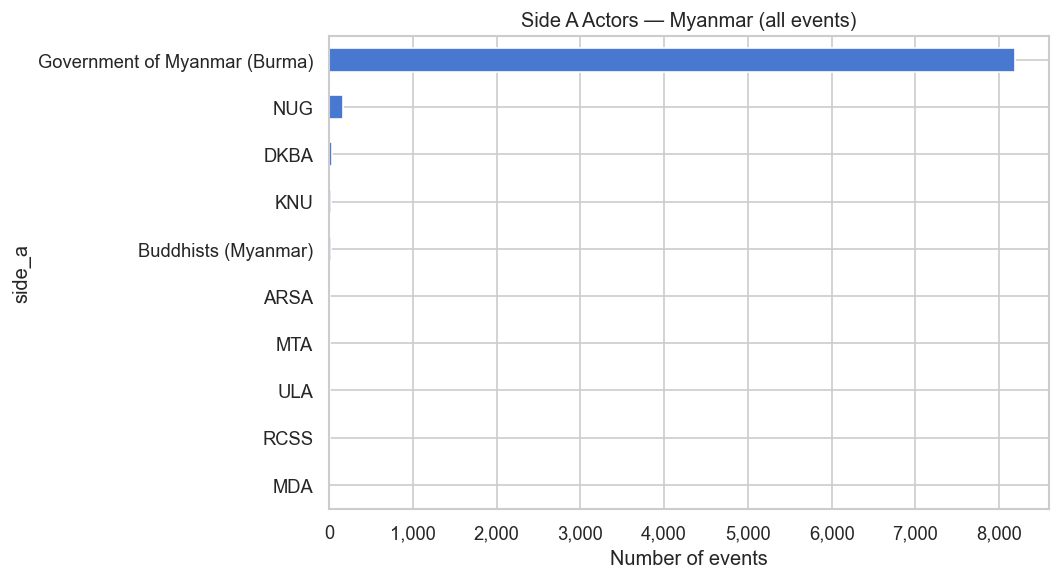

In [4]:
side_a_counts = mm['side_a'].value_counts()
print('All Side A actors:')
print(side_a_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
side_a_counts.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Side A Actors — Myanmar (all events)')
ax.set_xlabel('Number of events')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 4. Side B Actors (opposing party)

All Side B actors:
side_b
NUG                  2981
Civilians            2501
KNU                   806
KIO                   614
ULA                   442
PSLF                  295
KNPP                  228
MNDAA                 136
RCSS                  128
CNF                    70
SSPP                   49
DKBA 5                 31
MTA                    30
ARSA                   28
UWSA                   27
Muslims (Myanmar)      25
ABSDF                  20
NSCN-K                 18
PNLO                   17
RSO                    16
NMSP                   10
God's Army              2
BMA                     1
MDA - LM                1


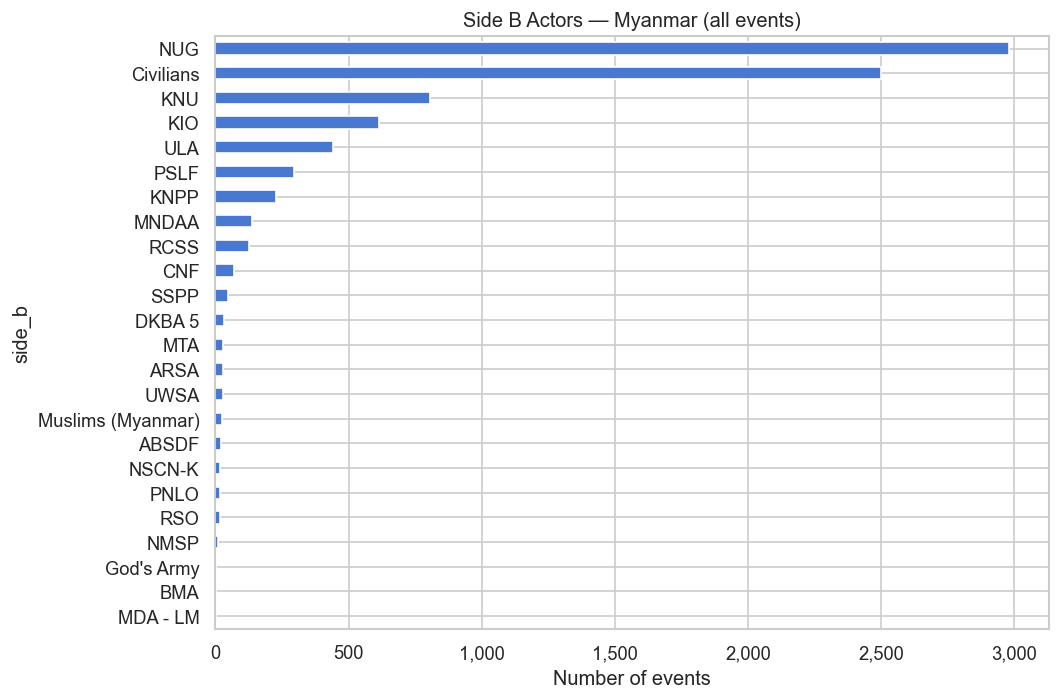

In [5]:
side_b_counts = mm['side_b'].value_counts()
print('All Side B actors:')
print(side_b_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 6))
side_b_counts.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Side B Actors — Myanmar (all events)')
ax.set_xlabel('Number of events')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 5. Actor breakdown by type of violence

Side A in state-based vs. non-state conflicts gives different actor profiles.

In [6]:
for vtype, grp in mm.groupby('violence_type'):
    print(f'\n=== {vtype} ===')
    print('  Side A:', grp['side_a'].value_counts().to_dict())
    print('  Side B:', grp['side_b'].value_counts().to_dict())


=== Non-state (2) ===
  Side A: {'DKBA': 35, 'Buddhists (Myanmar)': 25, 'MTA': 9, 'RCSS': 8, 'MDA': 1}
  Side B: {'KNU': 35, 'Muslims (Myanmar)': 25, 'UWSA': 17, 'MDA - LM': 1}

=== One-sided (3) ===
  Side A: {'Government of Myanmar (Burma)': 2286, 'NUG': 163, 'KNU': 27, 'ARSA': 17, 'ULA': 8}
  Side B: {'Civilians': 2501}

=== State-based (1) ===
  Side A: {'Government of Myanmar (Burma)': 5897}
  Side B: {'NUG': 2981, 'KNU': 771, 'KIO': 614, 'ULA': 442, 'PSLF': 295, 'KNPP': 228, 'MNDAA': 136, 'RCSS': 128, 'CNF': 70, 'SSPP': 49, 'DKBA 5': 31, 'MTA': 30, 'ARSA': 28, 'ABSDF': 20, 'NSCN-K': 18, 'PNLO': 17, 'RSO': 16, 'NMSP': 10, 'UWSA': 10, "God's Army": 2, 'BMA': 1}


## 6. Dyads and Conflicts

Total unique dyads: 31
dyad_name
Government of Myanmar (Burma) - NUG           2981
Government of Myanmar (Burma) - Civilians     2286
Government of Myanmar (Burma) - KNU            771
Government of Myanmar (Burma) - KIO            614
Government of Myanmar (Burma) - ULA            442
Government of Myanmar (Burma) - PSLF           295
Government of Myanmar (Burma) - KNPP           228
NUG - Civilians                                163
Government of Myanmar (Burma) - MNDAA          136
Government of Myanmar (Burma) - RCSS           128
Government of Myanmar (Burma) - CNF             70
Government of Myanmar (Burma) - SSPP            49
DKBA - KNU                                      35
Government of Myanmar (Burma) - DKBA 5          31
Government of Myanmar (Burma) - MTA             30
Government of Myanmar (Burma) - ARSA            28
KNU - Civilians                                 27
Buddhists (Myanmar) - Muslims (Myanmar)         25
Government of Myanmar (Burma) - ABSDF           2

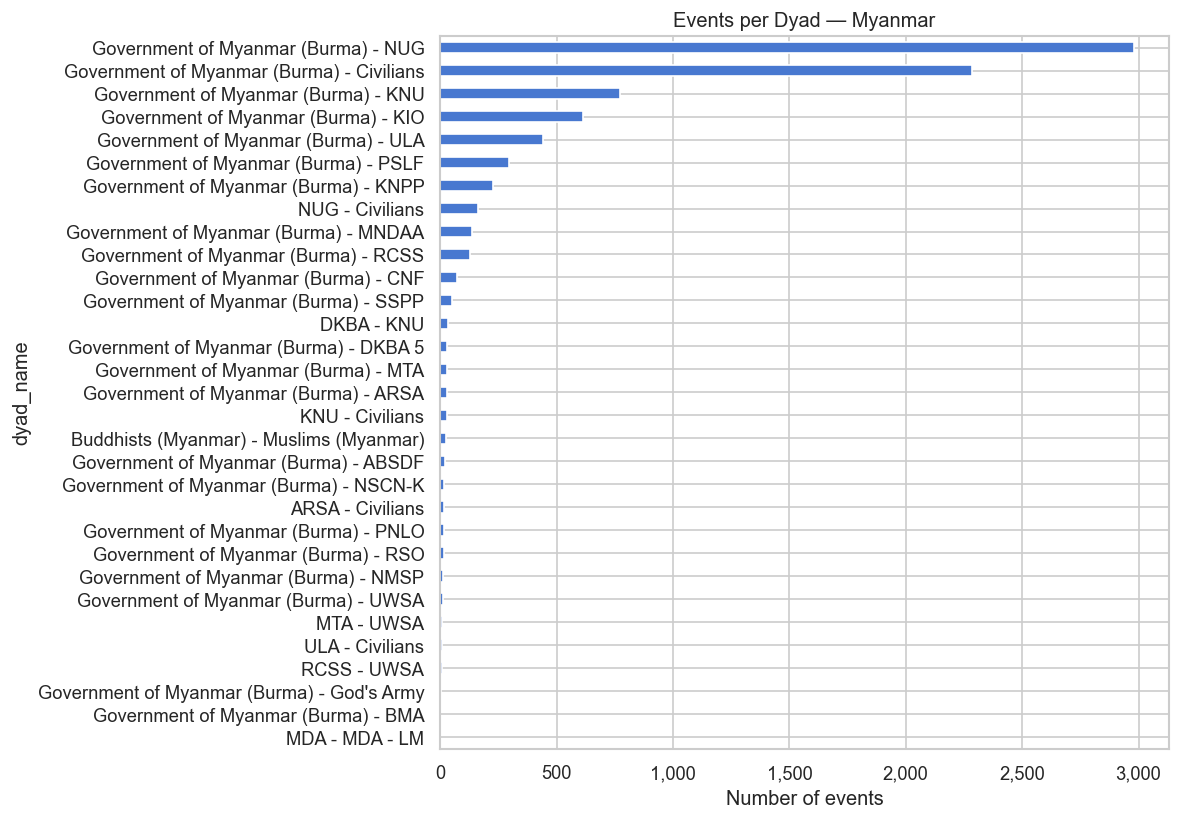

In [7]:
dyad_counts = mm['dyad_name'].value_counts()
print(f'Total unique dyads: {len(dyad_counts)}')
print(dyad_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 7))
dyad_counts.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Events per Dyad — Myanmar')
ax.set_xlabel('Number of events')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [8]:
conflict_counts = mm['conflict_name'].value_counts()
print(f'Total unique named conflicts: {len(conflict_counts)}')
print(conflict_counts.to_string())

Total unique named conflicts: 20
conflict_name
Myanmar (Burma): Government                  3383
Government of Myanmar (Burma) - Civilians    2286
Myanmar (Burma): Karen                        804
Myanmar (Burma): Kachin                       614
Myanmar (Burma): Arakan                       486
Myanmar (Burma): Karenni                      228
Myanmar (Burma): Shan                         207
NUG - Civilians                               163
Myanmar (Burma): Kokang                       136
DKBA - KNU                                     35
KNU - Civilians                                27
Buddhists (Myanmar) - Muslims (Myanmar)        25
Myanmar (Burma): Nagaland                      18
ARSA - Civilians                               17
Myanmar (Burma): Mon                           11
Myanmar (Burma): Wa                            10
MTA - UWSA                                      9
ULA - Civilians                                 8
RCSS - UWSA                                     8
MDA

## 7. Geographic Distribution — Province (adm_1)

adm_1
Sagaing region               1828
Shan state                   1218
Kayin state                   781
Rakhine state                 594
Magway region                 581
Mandalay region               509
Kachin state                  482
Chin state                    337
Kayah state                   332
Bago region                   327
Tanintharyi region            260
Mon state                     259
Bago division                 143
Yangon region                 143
Tanintharyi division          117
Yangon division                28
Karen state                    19
Naypyidaw Union territory      16
Ayeyarwady region              13
Ayeyarwady division            12
Mandalay division               8
Sagaing division                8
Sagaing district                6
Magwe division                  1


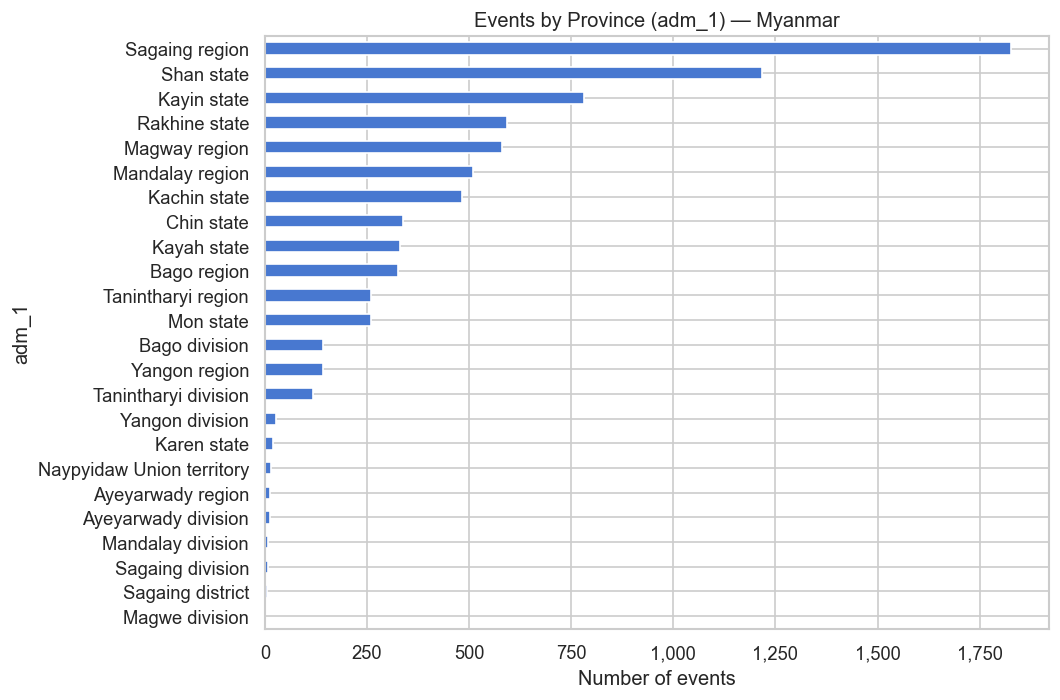

In [9]:
adm1_counts = mm['adm_1'].value_counts()
print(adm1_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 6))
adm1_counts.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Events by Province (adm_1) — Myanmar')
ax.set_xlabel('Number of events')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 8. Fatalities

In [10]:
death_cols = ['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best']
print('Total fatalities by category:')
print(mm[death_cols].sum().to_string())
print(f'\nMedian best estimate per event : {mm["best"].median()}')
print(f'Mean best estimate per event  : {mm["best"].mean():.2f}')
print(f'Max single event (best)       : {mm["best"].max()}')

Total fatalities by category:
deaths_a             7490
deaths_b             5458
deaths_civilians    13101
deaths_unknown       5511
best                31560

Median best estimate per event : 1.0
Mean best estimate per event  : 3.72
Max single event (best)       : 1000


In [11]:
top10 = mm.nlargest(10, 'best')[['date_start', 'conflict_name', 'dyad_name', 'adm_1', 'best', 'deaths_civilians']]
top10

,date_start,conflict_name,dyad_name,adm_1,best,deaths_civilians
185389,1995-01-31,MTA - UWSA,MTA - UWSA,Shan state,1000,0
184399,2017-08-30,Government of Myanmar (Burma) - Civilians,Government of Myanmar (Burma) - Civilians,Rakhine state,750,750
181024,1989-02-20,Myanmar (Burma): Karen,Government of Myanmar (Burma) - KNU,Karen state,627,0
184391,2017-08-27,Government of Myanmar (Burma) - Civilians,Government of Myanmar (Burma) - Civilians,Rakhine state,358,358
185388,1991-12-01,MTA - UWSA,MTA - UWSA,NaN,350,0
182489,1992-08-01,Myanmar (Burma): Karenni,Government of Myanmar (Burma) - KNPP,NaN,341,0
181086,1992-03-19,Myanmar (Burma): Karen,Government of Myanmar (Burma) - KNU,Kayin state,300,0
186306,2017-08-25,Myanmar (Burma): Arakan,Government of Myanmar (Burma) - ARSA,Rakhine state,276,0
184392,2017-08-27,Government of Myanmar (Burma) - Civilians,Government of Myanmar (Burma) - Civilians,Rakhine state,243,243
181046,1989-12-26,Myanmar (Burma): Karen,Government of Myanmar (Burma) - KNU,Kayin state,220,0


Total deaths (best estimate) by violence type:
violence_type
State-based (1)    20402
One-sided (3)       8876
Non-state (2)       2282


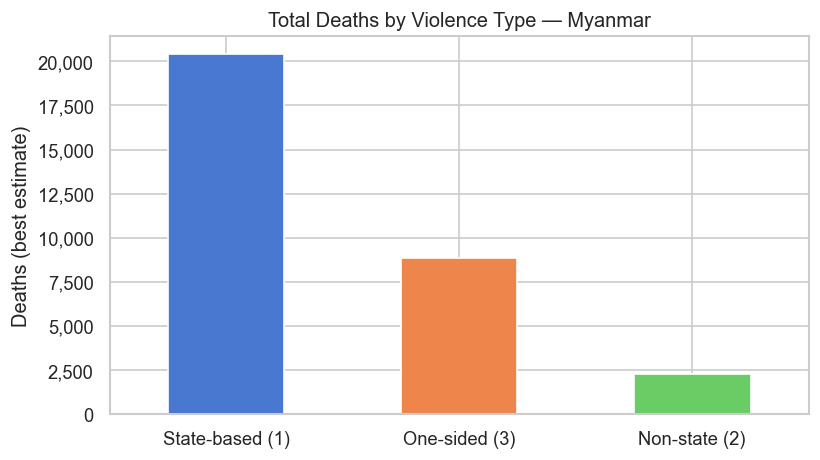

In [12]:
deaths_by_type = mm.groupby('violence_type')['best'].sum().sort_values(ascending=False)
print('Total deaths (best estimate) by violence type:')
print(deaths_by_type.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
deaths_by_type.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 3))
ax.set_title('Total Deaths by Violence Type — Myanmar')
ax.set_xlabel('')
ax.set_ylabel('Deaths (best estimate)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Time Series — Events and Deaths per Year

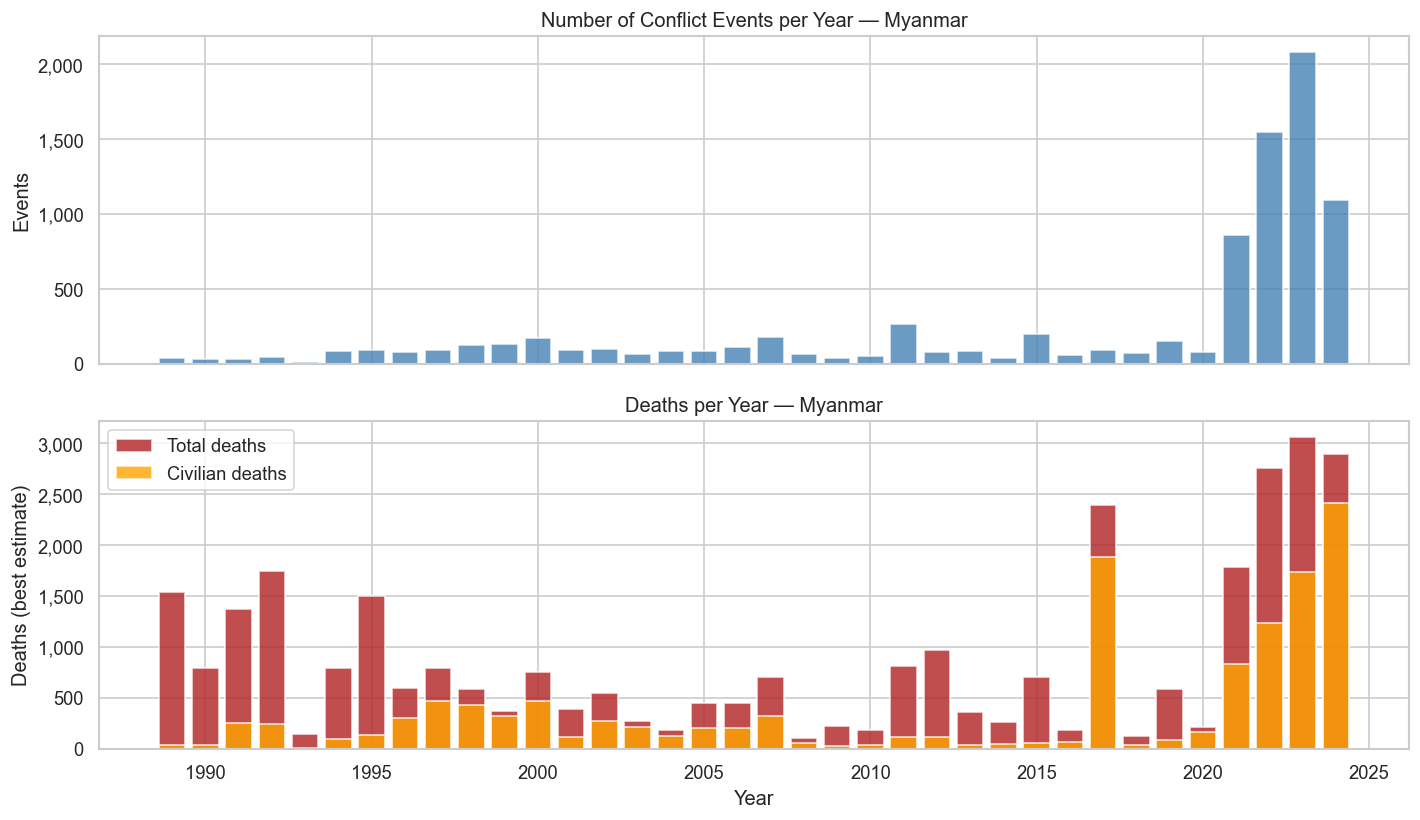

In [13]:
yearly = mm.groupby('year').agg(
    events=('id', 'count'),
    deaths=('best', 'sum'),
    civ_deaths=('deaths_civilians', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(yearly['year'], yearly['events'], color='steelblue', alpha=0.8)
axes[0].set_title('Number of Conflict Events per Year — Myanmar')
axes[0].set_ylabel('Events')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(yearly['year'], yearly['deaths'], color='firebrick', alpha=0.8, label='Total deaths')
axes[1].bar(yearly['year'], yearly['civ_deaths'], color='orange', alpha=0.8, label='Civilian deaths')
axes[1].set_title('Deaths per Year — Myanmar')
axes[1].set_ylabel('Deaths (best estimate)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend()

plt.xlabel('Year')
plt.tight_layout()
plt.show()

## 10. Time Series by Violence Type

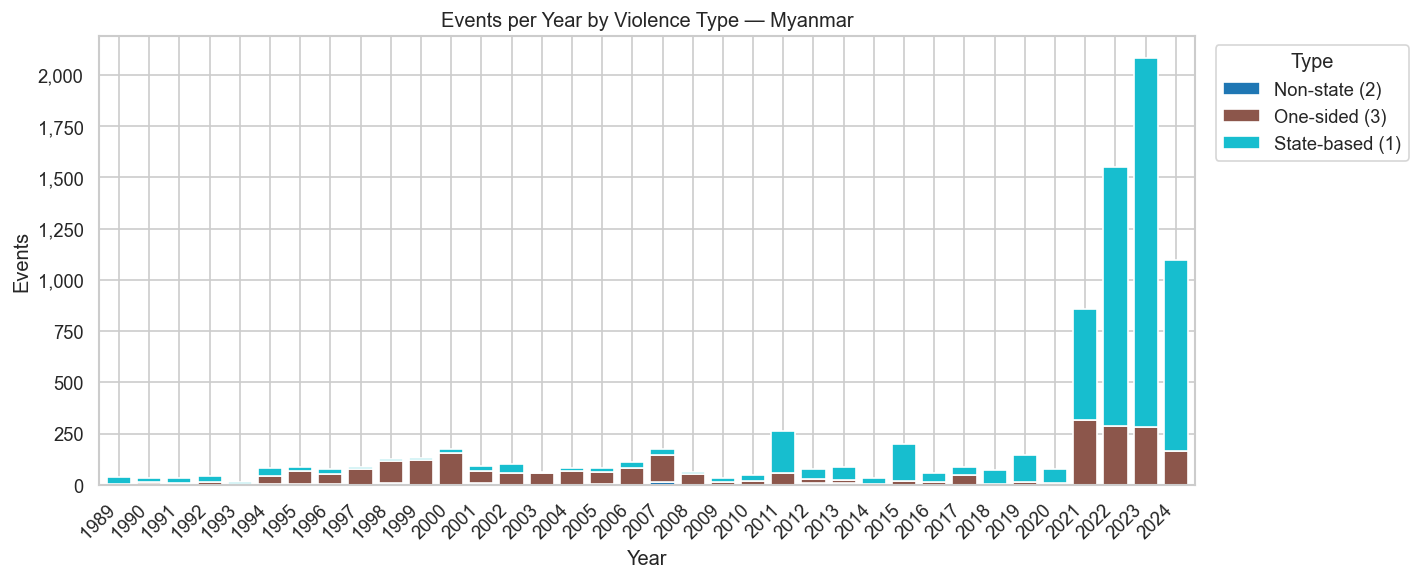

In [14]:
yearly_type = mm.groupby(['year', 'violence_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
yearly_type.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8)
ax.set_title('Events per Year by Violence Type — Myanmar')
ax.set_xlabel('Year')
ax.set_ylabel('Events')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Top Dyads Over Time

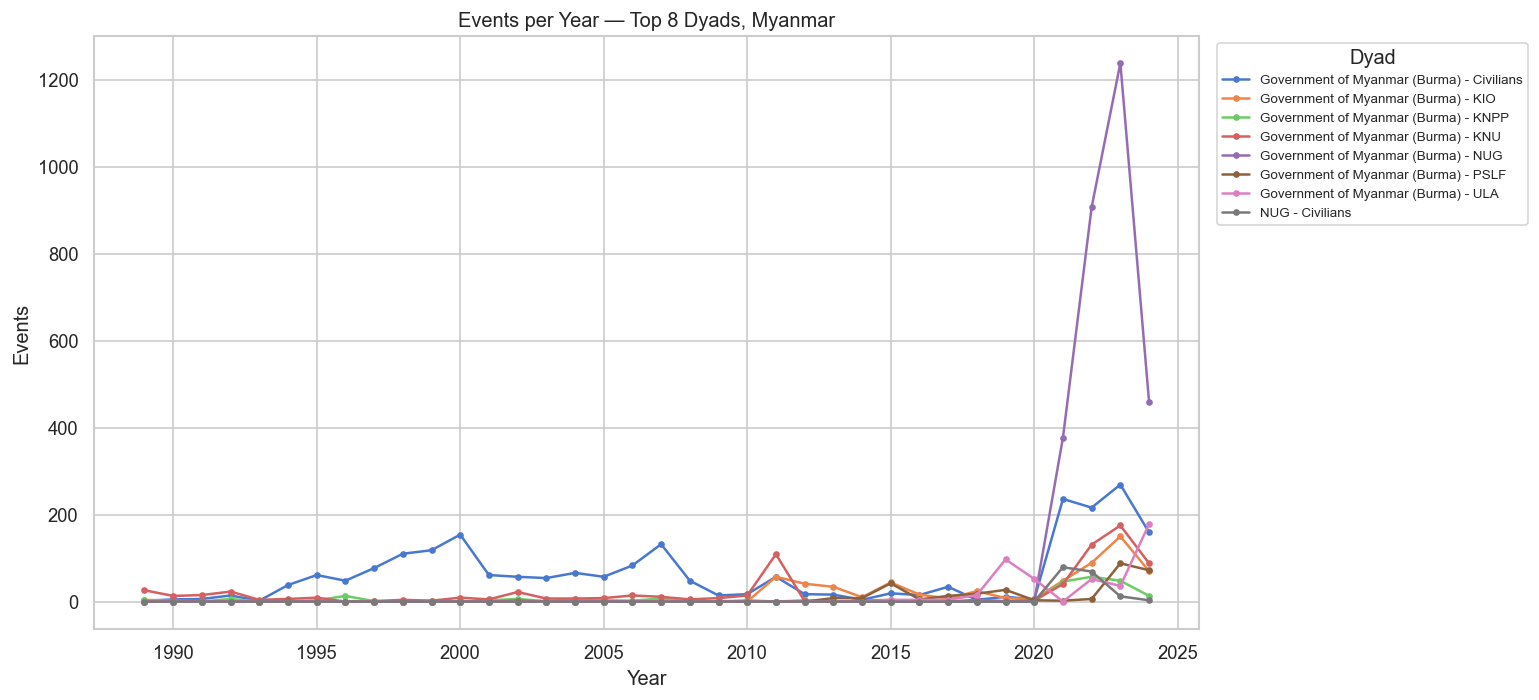

In [15]:
top_dyads = dyad_counts.head(8).index.tolist()
mm_top = mm[mm['dyad_name'].isin(top_dyads)]

dyad_year = mm_top.groupby(['year', 'dyad_name']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
dyad_year.plot(ax=ax, marker='o', markersize=3, linewidth=1.5)
ax.set_title('Events per Year — Top 8 Dyads, Myanmar')
ax.set_xlabel('Year')
ax.set_ylabel('Events')
ax.legend(title='Dyad', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 12. Summary Table — Actors with Fatality Totals

In [16]:
actor_summary = (
    mm.groupby('side_a')
    .agg(
        events=('id', 'count'),
        total_deaths=('best', 'sum'),
        civ_deaths=('deaths_civilians', 'sum'),
        first_year=('year', 'min'),
        last_year=('year', 'max'),
    )
    .sort_values('events', ascending=False)
)
print('Side A actor summary:')
actor_summary

Side A actor summary:


,events,total_deaths,civ_deaths,first_year,last_year
side_a,,,,,
Government of Myanmar (Burma),8183,28755,12573,1989,2024
NUG,163,198,198,2021,2024
DKBA,35,229,11,1994,2008
KNU,27,124,116,1989,2021
Buddhists (Myanmar),25,234,0,2001,2014
ARSA,17,92,92,2016,2024
MTA,9,1631,2,1990,1995
RCSS,8,118,0,2001,2022
ULA,8,109,109,2019,2024


In [17]:
sideb_summary = (
    mm.groupby('side_b')
    .agg(
        events=('id', 'count'),
        total_deaths=('best', 'sum'),
        civ_deaths=('deaths_civilians', 'sum'),
        first_year=('year', 'min'),
        last_year=('year', 'max'),
    )
    .sort_values('events', ascending=False)
)
print('Side B actor summary:')
sideb_summary

Side B actor summary:


,events,total_deaths,civ_deaths,first_year,last_year
side_b,,,,,
NUG,2981,4318,1659,2021,2024
Civilians,2501,8876,8856,1989,2024
KNU,806,5402,580,1989,2024
KIO,614,2673,484,1989,2024
ULA,442,1421,731,2015,2024
PSLF,295,847,393,1994,2024
KNPP,228,1027,124,1989,2024
MNDAA,136,721,154,2009,2024
RCSS,128,906,29,1996,2024


---
## 13. Dataset Structure Q&A

Quick answers to three common data-readiness questions about the Myanmar UCDP subset.

### Q1: Does the data have admin unit labels (admin1, admin2) or just lat/lon?

In [18]:
geo_cols = ['adm_1', 'adm_2', 'where_description', 'latitude', 'longitude', 'where_prec']
print('Column types:')
print(mm[geo_cols].dtypes)
print()
print(f'adm_1 coverage : {mm["adm_1"].notna().sum():,} non-null  |  {mm["adm_1"].isna().sum():,} null  ({mm["adm_1"].notna().mean():.1%})')
print(f'adm_2 coverage : {mm["adm_2"].notna().sum():,} non-null  |  {mm["adm_2"].isna().sum():,} null  ({mm["adm_2"].notna().mean():.1%})')
print(f'latitude       : {mm["latitude"].notna().sum():,} non-null')
print(f'longitude      : {mm["longitude"].notna().sum():,} non-null')
print()
print('Sample adm_1 values:', mm['adm_1'].dropna().unique()[:8].tolist())
print('Sample adm_2 values:', mm['adm_2'].dropna().unique()[:8].tolist())
print()
# where_prec: 1=exact point, 2=up to 25km, 3=up to 50km, 4=adm2, 5=adm1, 6=unknown, 7=country centroid
print('where_prec distribution (spatial precision code):')
prec_labels = {
    1: '1 – exact point',
    2: '2 – up to 25 km',
    3: '3 – up to 50 km',
    4: '4 – adm2 centroid',
    5: '5 – adm1 centroid',
    6: '6 – unknown area',
    7: '7 – country centroid',
}
prec = mm['where_prec'].value_counts().sort_index()
for code, count in prec.items():
    label = prec_labels.get(code, str(code))
    print(f'  {label}: {count:,}')

Column types:
adm_1                    str
adm_2                    str
where_description        str
latitude             float64
longitude            float64
where_prec             int64
dtype: object

adm_1 coverage : 8,022 non-null  |  454 null  (94.6%)
adm_2 coverage : 7,123 non-null  |  1,353 null  (84.0%)
latitude       : 8,476 non-null
longitude      : 8,476 non-null

Sample adm_1 values: ['Karen state', 'Yangon division', 'Kayin state', 'Mon state', 'Ayeyarwady division', 'Tanintharyi division', 'Rakhine state', 'Mandalay division']
Sample adm_2 values: ['Myawaddy district', 'Kawkareik district', 'Hpa-an district', 'Thaton district', 'Bogale district', 'Papun district', 'Kyaukpyu district', 'Dawai district']

where_prec distribution (spatial precision code):
  1 – exact point: 1,756
  2 – up to 25 km: 1,441
  3 – up to 50 km: 467
  4 – adm2 centroid: 720
  5 – adm1 centroid: 3,737
  6 – unknown area: 352
  7 – country centroid: 3


### Q2: What time period does the Myanmar UCDP data cover?

In [19]:
print(f'Earliest event start : {mm["date_start"].min().date()}')
print(f'Latest event end     : {mm["date_end"].max().date()}')
print(f'Years covered        : {mm["year"].min()} – {mm["year"].max()}  ({mm["year"].nunique()} distinct years)')
print()
print('Events per decade:')
decade = (mm['year'] // 10 * 10).value_counts().sort_index()
for d, n in decade.items():
    print(f'  {d}s : {n:,} events')

Earliest event start : 1989-01-01
Latest event end     : 2024-12-31
Years covered        : 1989 – 2024  (36 distinct years)

Events per decade:
  1980s : 37 events
  1990s : 714 events
  2000s : 986 events
  2010s : 1,075 events
  2020s : 5,664 events


### Q3: What does one row look like? — example rows

In [20]:
# Key columns for a quick read — one row from each violence type
key_cols = [
    'id', 'year', 'date_start', 'date_end',
    'type_of_violence', 'violence_type',
    'conflict_name', 'dyad_name',
    'side_a', 'side_b',
    'adm_1', 'adm_2', 'where_description',
    'latitude', 'longitude', 'where_prec',
    'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown',
    'best', 'high', 'low',
]

sample = pd.concat([
    mm[mm['violence_type'] == vt].sample(1, random_state=42)
    for vt in sorted(mm['violence_type'].unique())
]).reset_index(drop=True)[key_cols]

sample.T

,0,1,2
id,48809,51204,558683
year,2007,2007,2024
date_start,2007-12-18 00:00:00,2007-07-27 00:00:00,2024-08-30 00:00:00
date_end,2007-12-18 00:00:00,2007-07-27 00:00:00,2024-08-30 00:00:00
type_of_violence,2,3,1
violence_type,Non-state (2),One-sided (3),State-based (1)
conflict_name,DKBA - KNU,Government of Myanmar (Burma) - Civilians,Myanmar (Burma): Government
dyad_name,DKBA - KNU,Government of Myanmar (Burma) - Civilians,Government of Myanmar (Burma) - NUG
side_a,DKBA,Government of Myanmar (Burma),Government of Myanmar (Burma)
side_b,KNU,Civilians,NUG


In [21]:
# Full row with all 49 columns for one state-based event
pd.set_option('display.max_rows', 60)
mm[mm['violence_type'] == 'State-based (1)'].iloc[0].to_frame(name='value')

,value
id,71686
relid,MYA-1989-1-306-35
year,1989
active_year,True
code_status,Clear
type_of_violence,1
conflict_dset_id,221
conflict_new_id,221
conflict_name,Myanmar (Burma): Karen
dyad_dset_id,428
